In [139]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)

In [11]:
# Caminho da pasta
path = "gold_exports/"

# Importando as dimensões
df_customer = pd.read_csv(path + "dim_customer.csv")
df_date = pd.read_csv(path + "dim_date.csv")
df_exchange = pd.read_csv(path + "dim_exchange_rate.csv")
df_product = pd.read_csv(path + "dim_product.csv")

# Importando as tabelas de fatos
df_costs = pd.read_csv(path + "fact_costs.csv")
df_sales = pd.read_csv(path + "fact_sales.csv")

In [12]:
# Construção do Dataframe

df = df_sales.copy()

In [14]:
# Merge com produtos e clitens

df_customer = df_customer.rename(columns={"id": "client_id"})
df_product = df_product.rename(columns={"id": "product_id"})

df = df.merge(df_customer, on="client_id", how="left")
df = df.merge(df_product, on="product_id", how="left")

In [22]:
# Tratando datas

df["sale_date"] = pd.to_datetime(df["sale_date"])
df_costs["start_date"] = pd.to_datetime(df_costs["start_date"])

df = df.sort_values("sale_date")
df_costs = df_costs.sort_values("start_date")

In [23]:
# Merge com custos

df = pd.merge_asof(
    df,
    df_costs,
    left_on="sale_date",
    right_on="start_date",
    by="product_id",
    direction="backward"
)

In [24]:
# Adicionando o câmbio do dia

df_exchange["date"] = pd.to_datetime(df_exchange["date"])

df = df.merge(
    df_exchange,
    left_on="sale_date",
    right_on="date",
    how="left"
)

In [26]:
# Criando colunas adicionais com métricas

# Custo unitário em BRL
df['custo_unitario_brl'] = df['usd_price'] * df['usd_to_brl']

# Custo total da transação em BRL
df['custo_total_brl'] = df['custo_unitario_brl'] * df['quantity']

# Lucro
df["lucro"] = df["total_amount"] - df["custo_total_brl"]

# Identificador de prejuízo
df['prejuizo'] = df['lucro'] < 0

In [27]:
df

,id_x,client_id,product_id,sale_date,quantity,total_amount,name_x,city,reference_city,state,...,sale_price,id_y,start_date,usd_price,date,usd_to_brl,custo_unitario_brl,custo_total_brl,lucro,prejuizo
0,1230,17,91,2023-01-01,4,512566.80,Luís Paiva Costa Cardoso Coelho,Corumbá,Corumbá,MS,...,134886.02,763,2022-03-16,26303.31,2023-01-01,5.2171,137226.998601,5.489080e+05,-36341.194404,True
1,8211,14,67,2023-01-01,3,257367.00,Gabriela Silva Vieira Amaral,Itacoatiara,Itacoatiara,AM,...,85789.05,560,2022-06-17,16720.73,2023-01-01,5.2171,87233.720483,2.617012e+05,-4334.161449,True
2,666,14,15,2023-01-01,5,132524.05,Gabriela Silva Vieira Amaral,Itacoatiara,Itacoatiara,AM,...,27899.76,123,2022-12-06,5325.40,2023-01-01,5.2171,27783.144340,1.389157e+05,-6391.671700,True
3,5256,19,78,2023-01-01,12,1461139.00,Renata Lima Gomes Coelho Mendonça,Maceió,Maceió,AL,...,121761.56,662,2022-10-14,23053.04,2023-01-01,5.2171,120270.014984,1.443240e+06,17898.820192,False
4,3549,10,53,2023-01-01,13,662886.25,Débora Paiva,Santarém,Santarém,PA,...,53675.01,463,2022-07-19,9958.63,2023-01-01,5.2171,51955.168573,6.754172e+05,-12530.941449,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9890,6141,1,56,2024-12-31,2,81679.10,Femininos Oliveira Antunes,Aratu,Candeias,BA,...,42988.77,478,2022-12-19,8087.59,2024-12-31,6.1917,50075.931003,1.001519e+05,-18472.762006,True
9891,5650,32,39,2024-12-31,1,28151.35,Daniela Teixeira Antunes Coelho Batista,Porto Seguro,Porto Seguro,BA,...,29632.83,342,2020-10-16,5270.87,2024-12-31,6.1917,32635.645779,3.263565e+04,-4484.295779,True
9892,8762,48,33,2024-12-31,13,87305.00,Letícia Torres Peixoto Oliveira,Suape,Ipojuca,PE,...,6715.77,288,2024-04-10,1325.97,2024-12-31,6.1917,8210.008449,1.067301e+05,-19425.109837,True
9893,5451,7,27,2024-12-31,9,141172.85,Bianca Barros Rocha Torres Siqueira,Cabedelo,Cabedelo,PB,...,16511.45,247,2022-07-12,3051.23,2024-12-31,6.1917,18892.300791,1.700307e+05,-28857.857119,True


In [44]:
# Dataframe auxiliar com dados diários

df_daily = df.groupby("sale_date").agg({
    "total_amount": "sum",
    "lucro": "sum",
    "id_x": "count"
}).rename(columns={"id_x": "orders"})

In [45]:
df_date["date"] = pd.to_datetime(df_date["date"])

df_daily = df_date.merge(
    df_daily,
    left_on="date",
    right_on="sale_date",
    how="left"
)

In [46]:
df_daily[["total_amount", "lucro", "orders"]] = \
    df_daily[["total_amount", "lucro", "orders"]].fillna(0)

In [47]:
df_daily

,date_id,date,day,month,month_name,year,quarter,day_of_week,day_name,is_weekend,total_amount,lucro,orders
0,20160101,2016-01-01,1,1,January,2016,1,5,Friday,f,0.0,0.0,0.0
1,20160102,2016-01-02,2,1,January,2016,1,6,Saturday,t,0.0,0.0,0.0
2,20160103,2016-01-03,3,1,January,2016,1,0,Sunday,t,0.0,0.0,0.0
3,20160104,2016-01-04,4,1,January,2016,1,1,Monday,f,0.0,0.0,0.0
4,20160105,2016-01-05,5,1,January,2016,1,2,Tuesday,f,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3647,20251226,2025-12-26,26,12,December,2025,4,5,Friday,f,0.0,0.0,0.0
3648,20251227,2025-12-27,27,12,December,2025,4,6,Saturday,t,0.0,0.0,0.0
3649,20251228,2025-12-28,28,12,December,2025,4,0,Sunday,t,0.0,0.0,0.0
3650,20251229,2025-12-29,29,12,December,2025,4,1,Monday,f,0.0,0.0,0.0


In [48]:
# Criando métricas

df_daily["ticket_medio"] = df_daily["total_amount"] / df_daily["orders"]
df_daily["ticket_medio"] = df_daily["ticket_medio"].fillna(0)

In [54]:
# Igualando ambos os dataframes para o mesmo período
df_daily = df_daily[
    (df_daily["date"] >= "2023-01-01") &
    (df_daily["date"] <= "2024-12-31")
]

df_daily = df_daily.copy()

## EDA

### => Análise Temporal

In [70]:
# Análise de Receita e Lucro

# Dados agregados por ano, 2023 e 2024
summary = df_daily.groupby("year").agg({
    "total_amount": "sum",
    "lucro": "sum",
    "date": "count"
}).rename(columns={
    "total_amount": "receita_total",
    "lucro": "lucro_total",
    "date": "num_dias"
})

# Médias
summary["receita_media_dia"] = summary["receita_total"] / summary["num_dias"]
summary["lucro_medio_dia"] = summary["lucro_total"] / summary["num_dias"]

# Total do período
total = pd.DataFrame({
    "receita_total": [df_daily["total_amount"].sum()],
    "lucro_total": [df_daily["lucro"].sum()],
    "num_dias": [df_daily["date"].nunique()]
})

total["receita_media_dia"] = total["receita_total"] / total["num_dias"]
total["lucro_medio_dia"] = total["lucro_total"] / total["num_dias"]

total.index = ["Total"]

# Juntando tudo
summary_final = pd.concat([summary, total])

summary_final = summary_final[[
    "receita_total",
    "lucro_total",
    "receita_media_dia",
    "lucro_medio_dia" ]]

# Fortando para melhor visualização
summary_final.style.format({
    "receita_total": "R$ {:,.0f}",
    "lucro_total": "R$ {:,.0f}",
    "receita_media_dia": "R$ {:,.0f}",
    "lucro_medio_dia": "R$ {:,.0f}"
})

,receita_total,lucro_total,receita_media_dia,lucro_medio_dia
2023,"R$ 1,288,827,295","R$ -16,807,948","R$ 3,531,034","R$ -46,049"
2024,"R$ 1,321,452,216","R$ -121,612,713","R$ 3,610,525","R$ -332,275"
Total,"R$ 2,610,279,511","R$ -138,420,661","R$ 3,570,834","R$ -189,358"


#### Indicadores Consolidados

A análise dos indicadores evidencia um descolamento relevante entre receita e rentabilidade ao longo do período.

Enquanto a receita média diária apresentou leve crescimento, passando de R\\$ 3.53M em 2023 para R\\$ 3.61M em 2024 (+2.3%), o lucro médio diário sofreu uma deterioração acentuada, saindo de -R\\$ 46 mil para -R\\$ 332 mil.

Isso representa uma piora superior a 7 vezes no resultado operacional diário.

Esse comportamento indica que o aumento de receita não foi suficiente para compensar o crescimento dos custos, resultando em uma deterioração significativa da eficiência operacional.

O cenário sugere que o problema central do negócio não está na geração de receita, mas sim na estrutura de custos e na compressão de margens ao longo do tempo.

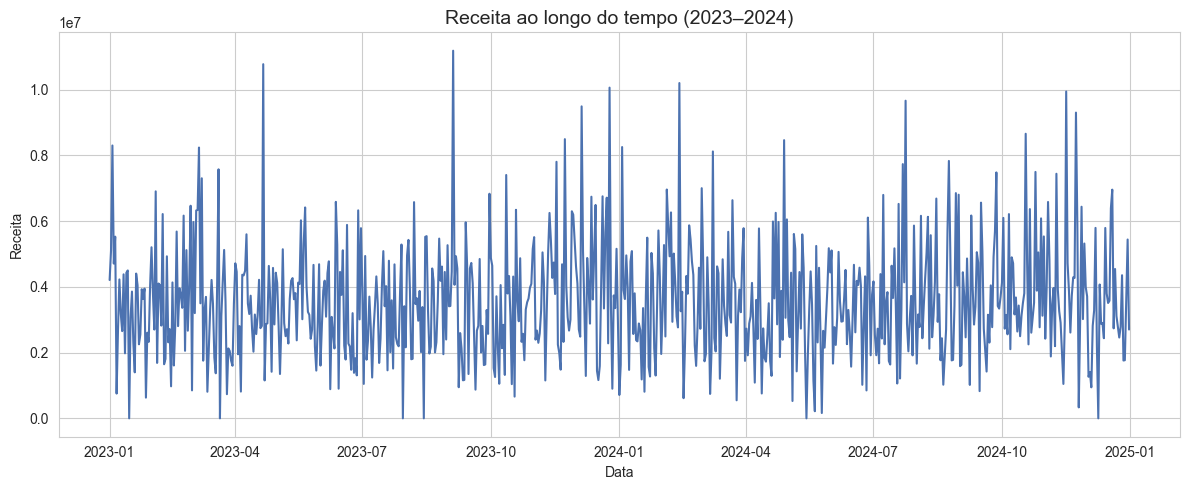

In [55]:
# Receita ao longo do tempo

sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df_daily,
    x="date",
    y="total_amount",
    color="#4C72B0"
)

plt.title("Receita ao longo do tempo (2023–2024)", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Receita")

plt.tight_layout()
plt.show()

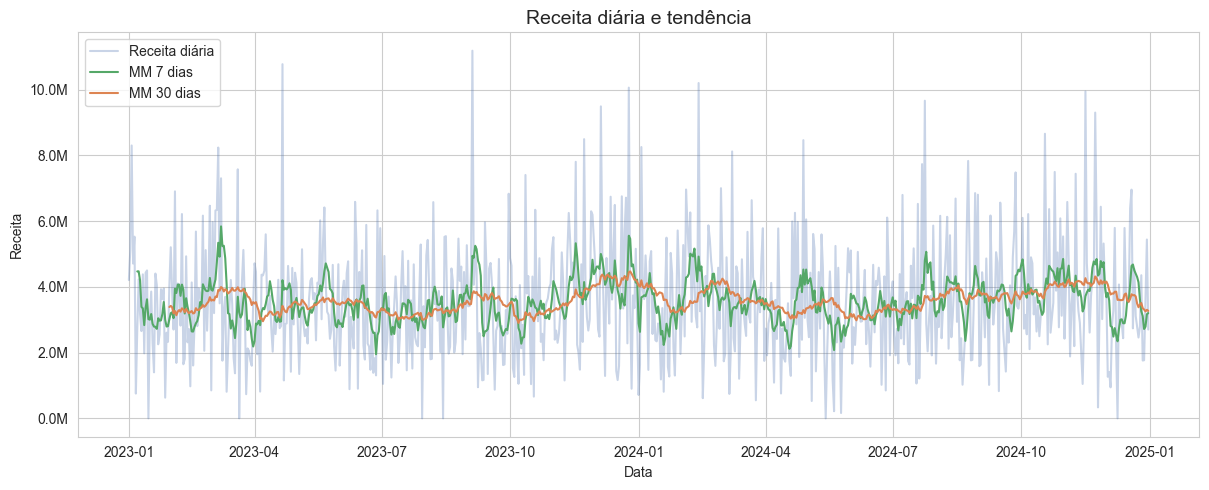

In [59]:
# Adicionando média móvel 7 e 30 dias e tendência

df_daily["receita_mm7"] = df_daily["total_amount"].rolling(window=7).mean()
df_daily["receita_mm30"] = df_daily["total_amount"].rolling(window=30).mean()

plt.figure(figsize=(12, 5))

# Receita diária
sns.lineplot(
    data=df_daily,
    x="date",
    y="total_amount",
    alpha=0.3,
    label="Receita diária",
    color="#4C72B0"
)

# Média móvel 7 dias (curto prazo)
sns.lineplot(
    data=df_daily,
    x="date",
    y="receita_mm7",
    label="MM 7 dias",
    color="#55A868"
)

# Média móvel 30 dias (tendência)
sns.lineplot(
    data=df_daily,
    x="date",
    y="receita_mm30",
    label="MM 30 dias",
    color="#DD8452"
)

plt.title("Receita diária e tendência", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Receita")

plt.legend()
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
plt.show()

**Insight**

##### Comportamento da Receita ao Longo do Tempo

A receita apresenta alta volatilidade no curto prazo, com variações frequentes ao longo dos dias, caracterizando um comportamento instável quando observada granularmente.

No entanto, ao analisar a média móvel de 30 dias, observa-se um padrão relativamente estável ao longo de todo o período, sem evidência de tendência consistente de crescimento ou queda.

Esse comportamento sugere que, apesar das oscilações pontuais, o negócio opera em um patamar estável de receita, sem expansão orgânica significativa no período analisado.

In [62]:
# Análise do lucro

df_daily = df_daily.copy()

df_daily["lucro_mm7"] = df_daily["lucro"].rolling(window=7).mean()
df_daily["lucro_mm30"] = df_daily["lucro"].rolling(window=30).mean()

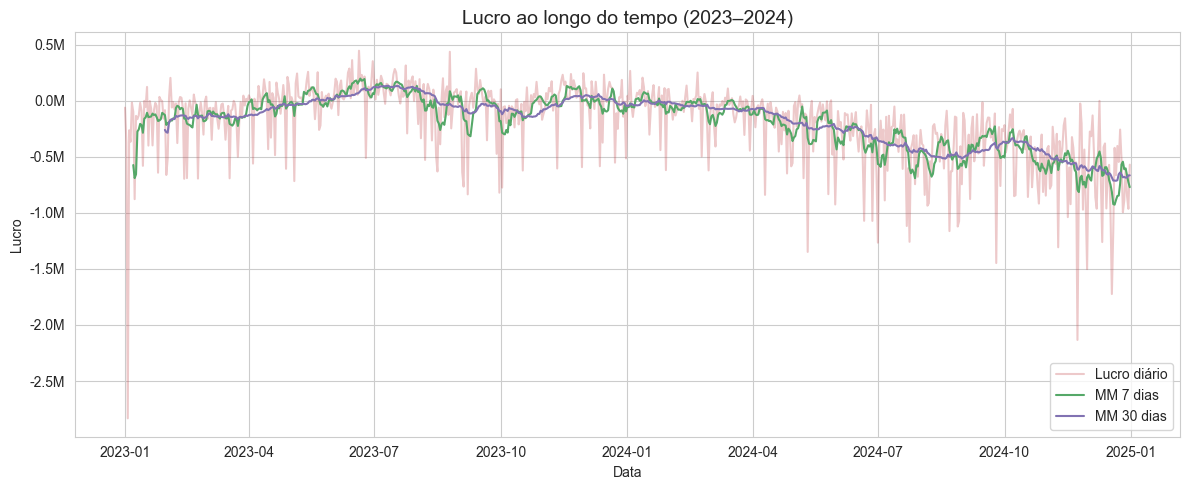

In [64]:
# Gráfico

plt.figure(figsize=(12, 5))

# Lucro diário
sns.lineplot(
    data=df_daily,
    x="date",
    y="lucro",
    alpha=0.3,
    label="Lucro diário",
    color="#C44E52"
)

# MM 7 dias
sns.lineplot(
    data=df_daily,
    x="date",
    y="lucro_mm7",
    label="MM 7 dias",
    color="#55A868"
)

# MM 30 dias
sns.lineplot(
    data=df_daily,
    x="date",
    y="lucro_mm30",
    label="MM 30 dias",
    color="#8172B2"
)

# Formatação eixo Y em milhões
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.title("Lucro ao longo do tempo (2023–2024)", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Lucro")

plt.legend()
plt.tight_layout()
plt.show()

**Insight**

##### Análise do Lucro ao Longo do Tempo

A análise do lucro, como esperado, revela um cenário estruturalmente desfavorável para o negócio.

Apesar de uma receita total superior a R\\$ 2.6 bilhões no período, o resultado acumulado foi negativo em aproximadamente R\\$ 138 milhões, indicando uma margem negativa de cerca de 5.3%.

Observa-se que:
- A maior parte dos dias apresenta prejuízo, evidenciando um padrão recorrente e não pontual
- Existe um outlier significativo no início do período (03/01/2023), com prejuízo extremamente elevado, que impacta a escala do gráfico
- Ao longo de 2023, o lucro oscila em torno de um intervalo relativamente estável
- Em 2024, observa-se uma deterioração clara, com aumento da frequência e intensidade de prejuízos

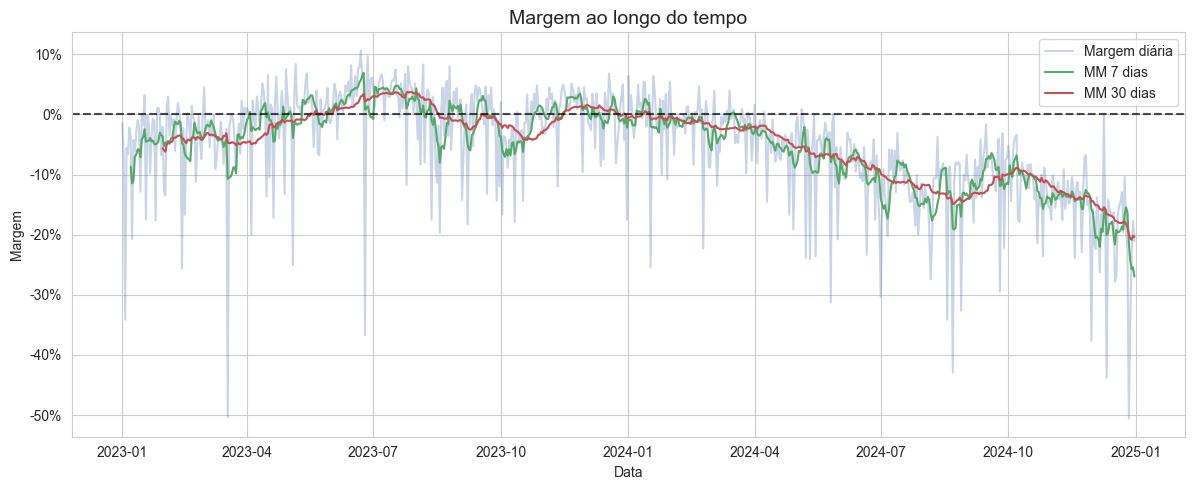

In [73]:
# Análise da margem ao longo do tempo

df_daily["margem"] = df_daily["lucro"] / df_daily["total_amount"]

# Evitando divisão por zero
df_daily["margem"] = df_daily["margem"].fillna(0)

# Médias móveis
df_daily["margem_mm7"] = df_daily["margem"].rolling(7).mean()
df_daily["margem_mm30"] = df_daily["margem"].rolling(30).mean()

# Gráfico
plt.figure(figsize=(12, 5))

# Margem diária
sns.lineplot(
    data=df_daily,
    x="date",
    y="margem",
    alpha=0.3,
    label="Margem diária",
    color="#4C72B0"
)

# MM 7 dias
sns.lineplot(
    data=df_daily,
    x="date",
    y="margem_mm7",
    label="MM 7 dias",
    color="#55A868"
)

# MM 30 dias (principal)
sns.lineplot(
    data=df_daily,
    x="date",
    y="margem_mm30",
    label="MM 30 dias",
    color="#C44E52"
)

plt.title("Margem ao longo do tempo", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Margem")

plt.axhline(0, linestyle="--", color="black", alpha=0.7)  # linha de break-even

plt.legend()
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:.0%}'))
plt.show()

**Insight**

A margem apresenta comportamento consistente com o observado no lucro, mantendo-se relativamente estável ao longo de 2023 e deteriorando-se de forma significativa em 2024.

Esse padrão reforça que a piora do resultado não está associada à receita, mas sim à compressão de margens ao longo do tempo.

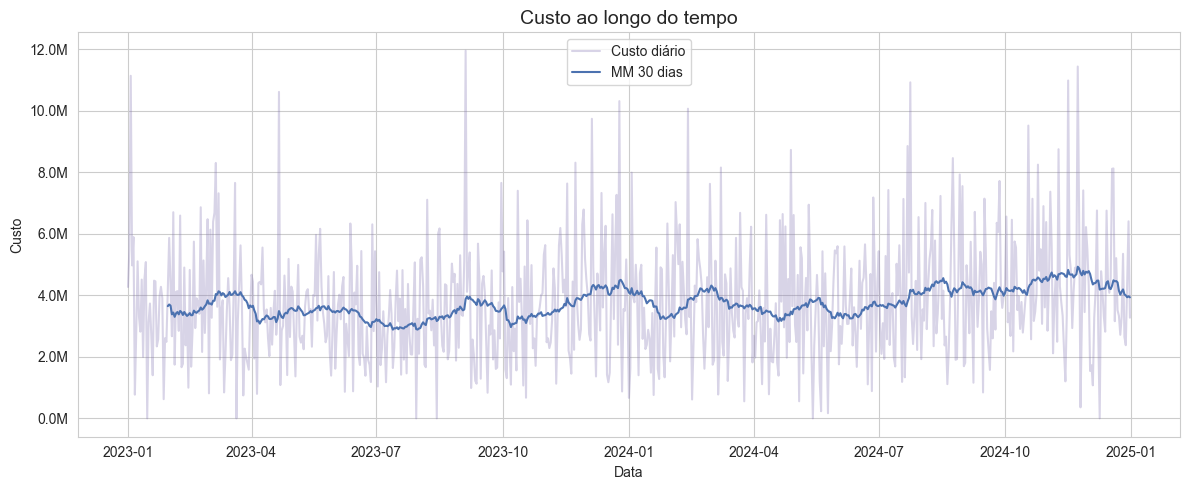

In [78]:
# Análise do custo

df_daily["cost"] = df_daily["total_amount"] - df_daily["lucro"]
df_daily["cost_mm30"] = df_daily["cost"].rolling(30).mean()

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df_daily,
    x="date",
    y="cost",
    alpha=0.3,
    label="Custo diário",
    color="#8172B2"
)

sns.lineplot(
    data=df_daily,
    x="date",
    y="cost_mm30",
    label="MM 30 dias",
    color="#4C72B0"
)

plt.title("Custo ao longo do tempo", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Custo")

# Formatar eixo em milhões
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.legend()
plt.tight_layout()
plt.show()

##### Evolução dos Custos

Apesar da presença de picos elevados, os custos não apresentam uma tendência clara de crescimento ao longo do período quando analisados por meio da média móvel.

Esse comportamento sugere que a deterioração do lucro não está associada exclusivamente ao aumento absoluto dos custos, mas possivelmente a uma compressão de margem, onde os custos passam a representar uma proporção maior da receita.

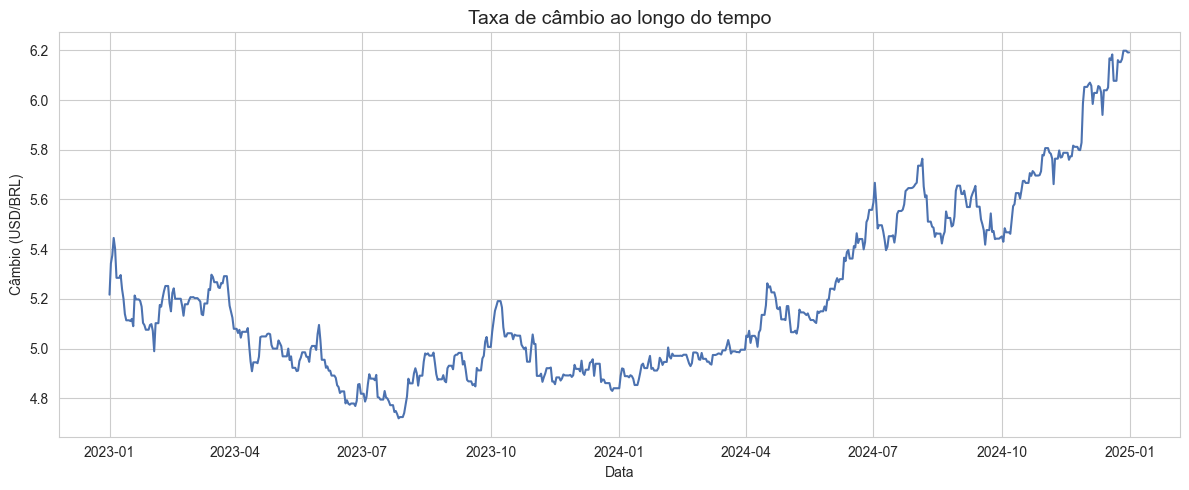

In [83]:
# Análise incorporando o câmbio ao período

df_exchange["date"] = pd.to_datetime(df_exchange["date"])

df_daily = df_daily.merge(
    df_exchange[["date", "usd_to_brl"]],
    on="date",
    how="left"
)

# Gráfico
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df_daily,
    x="date",
    y="usd_to_brl",
    color="#4C72B0"
)

plt.title("Taxa de câmbio ao longo do tempo", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Câmbio (USD/BRL)")

plt.tight_layout()
plt.show()

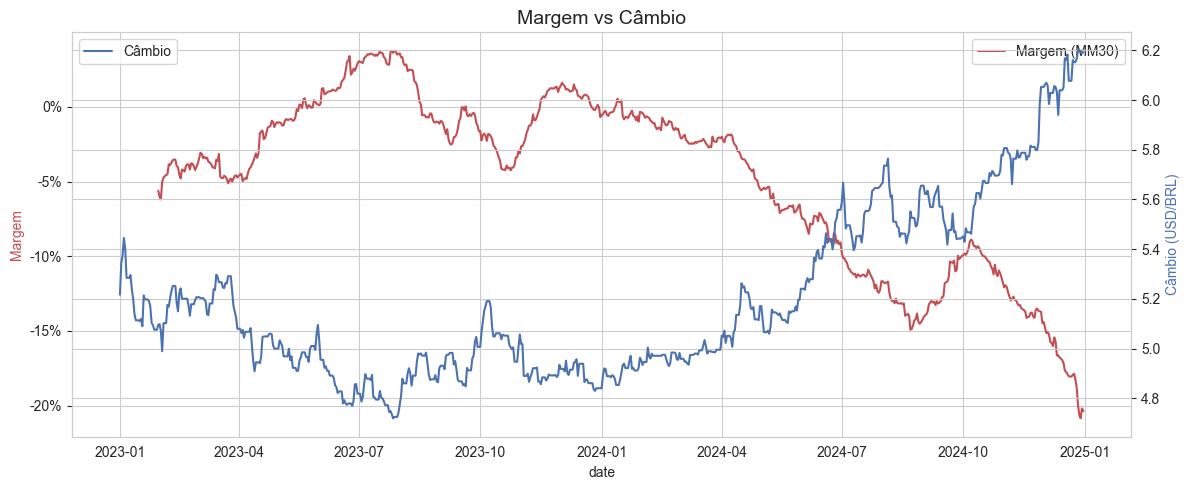

In [85]:
# Câmbio e margem combinados

fig, ax1 = plt.subplots(figsize=(12, 5))

# Margem (eixo esquerdo)
sns.lineplot(
    data=df_daily,
    x="date",
    y="margem_mm30",
    ax=ax1,
    color="#C44E52",
    label="Margem (MM30)"
)

ax1.set_ylabel("Margem", color="#C44E52")

# Formatar margem em %
import matplotlib.ticker as ticker
ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:.0%}')
)

# Câmbio (eixo direito)
ax2 = ax1.twinx()

sns.lineplot(
    data=df_daily,
    x="date",
    y="usd_to_brl",
    ax=ax2,
    color="#4C72B0",
    label="Câmbio"
)

ax2.set_ylabel("Câmbio (USD/BRL)", color="#4C72B0")

plt.title("Margem vs Câmbio", fontsize=14)

plt.tight_layout()
plt.show()

**Insight**

##### Impacto do Câmbio na Margem

A análise conjunta entre a margem e a taxa de câmbio revela uma relação inversa clara entre as variáveis.

Observa-se que, a partir do início de 2024, a valorização do dólar coincide com uma deterioração significativa da margem, indicando que o aumento dos custos de importação impacta diretamente a rentabilidade do negócio.

Os dois indicadores apresentam comportamentos praticamente espelhados ao longo do período, reforçando a hipótese de que a compressão de margem está fortemente associada à variação cambial.

Isso sugere que a exposição cambial é um fator crítico para o negócio, indicando a necessidade de estratégias de mitigação, como hedge cambial ou revisão do mix de produtos.

Cabe destacar que o impacto do câmbio não se refletiu de forma tão evidente na análise direta dos custos. Isso pode ser explicado pelas premissas adotadas na modelagem, como a utilização do custo vigente com base na data imediatamente anterior à venda e a aplicação da taxa de câmbio no dia da transação.

Essas simplificações, embora necessárias, podem suavizar ou distorcer parcialmente a dinâmica real dos custos, tornando a análise da margem um indicador mais sensível para capturar esse efeito.

### => Análise Transacional

- - - Análide de Produtos

In [86]:
# % de transações que dão prejuízo

prejuizo_pct = (df["lucro"] < 0).mean()
print(f"{prejuizo_pct:.2%}")

62.32%


**Incidência de Prejuízo**: A maioria das transações (aproximadamente 62%) apresenta resultado negativo, reforçando o caráter estrutural do prejuízo observado ao longo do período.

In [93]:
df_prod = df.groupby(["product_id", "name_y"]).agg({
    "lucro": "sum",
    "total_amount": "sum",
    "id_x": "count"
}).rename(columns={"id_x": "num_vendas"}).reset_index()

df_prod

,product_id,name_y,lucro,total_amount,num_vendas
0,1,Transponder AIS Maré Magnum,-1.953639e+05,17187280.35,67
1,2,Transponder Furuno Marlin,-6.847466e+05,8862231.15,71
2,3,Radar Furuno Pulse Leviathan,-2.326928e+05,4322136.25,64
3,4,Rádio AIS Hydro Tidal Zen,-7.799169e+04,1915160.00,76
4,5,Piloto Automático Furuno Storm,-1.003588e+06,13494880.35,68
...,...,...,...,...,...
145,146,Corrente Delta Vox Ion,-8.574801e+03,277313.60,72
146,147,Corrente Danforth Force Leviathan Impulse,-7.250463e+04,1326261.95,58
147,148,Âncora Delta Force Barracuda Mako,-9.591091e+04,2701447.25,68
148,149,Cabo de Nylon Bruce Core,-1.397855e+04,637139.85,65


In [96]:
# Apenas produtos que dão prejuízo

df_prod_prejuizo = df_prod[df_prod["lucro"] < 0].sort_values("lucro")

df_prod_prejuizo

,product_id,name_y,lucro,total_amount,num_vendas
71,72,Motor de Popa Volvo Hydro Dash 256HP,-3.980909e+07,63057815.65,78
82,83,Motor Diesel Yanmar Dash Nitro 184HP,-1.860701e+07,44377440.00,44
73,74,Motor de Popa Honda Torque 228HP,-6.341764e+06,59764356.15,85
70,71,Motor Elétrico Torqeedo Pulse 300HP,-5.788013e+06,81567066.65,78
54,55,Motor Diesel Volvo Flow Oceanic 259HP,-5.360513e+06,61224375.00,74
...,...,...,...,...,...
102,103,Âncora Delta Swift,-5.716924e+03,1136043.45,80
104,105,Cabo de Nylon Danforth Prime,-4.645574e+03,145543.95,61
65,66,Motor de Popa Tohatsu Poseidon Helix Prime 135HP,-2.934103e+03,5470546.80,58
132,133,Âncora Bruce Core Pulse,-2.692416e+03,987146.60,70


**Insight**: 127 dos 150 (~84.7%) apresentam prejuízo no período

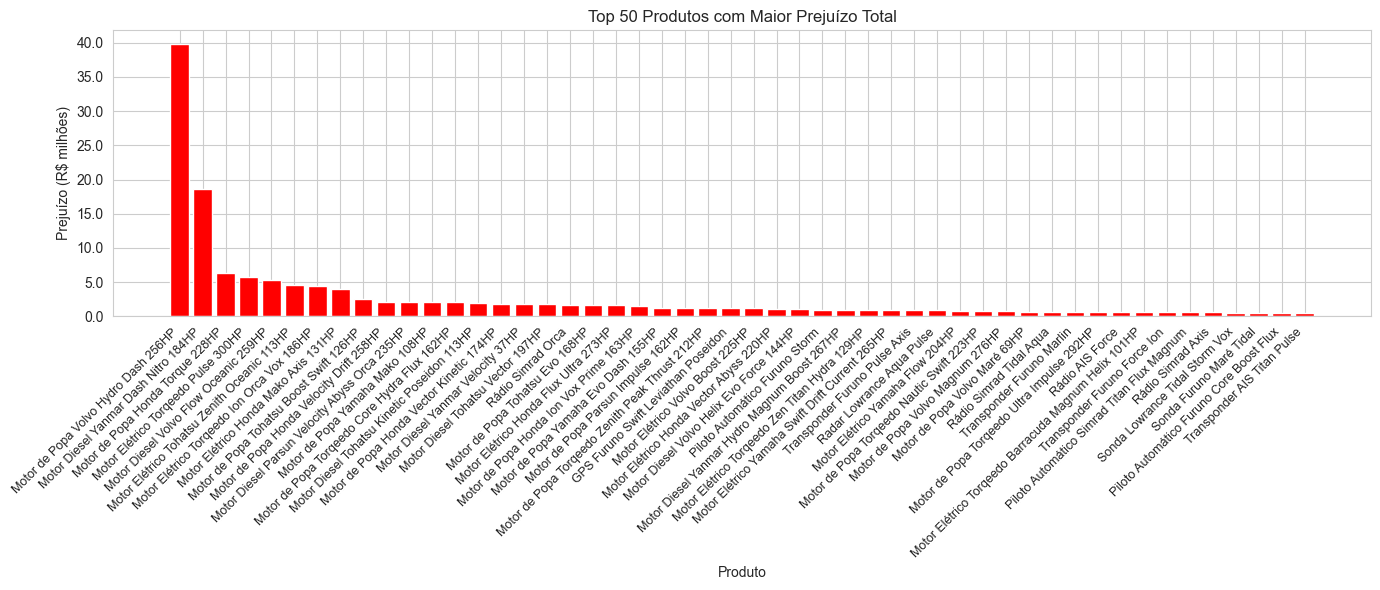

In [99]:
# Gráfico

# Filtrando apenas os top 20 maiores prejuízos e inverte o sinal
df_top_prejuizo = df_prod_prejuizo.nsmallest(50, 'lucro').copy()
df_top_prejuizo['prejuizo_positivo'] = df_top_prejuizo['lucro'].abs()

# Gráfico
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(df_top_prejuizo['name_y'], df_top_prejuizo['prejuizo_positivo'], color='red')

ax.set_title('Top 50 Produtos com Maior Prejuízo Total')
ax.set_xlabel('Produto')
ax.set_ylabel('Prejuízo (R$ milhões)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}'))

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

      category  preco_medio  preco_mediano  preco_max
0    Ancoragem    2663.9964       2727.065    4785.56
1  Eletrônicos   17924.9526      14111.410   39705.50
2    Propulsão   83462.5118      86173.805  148198.23


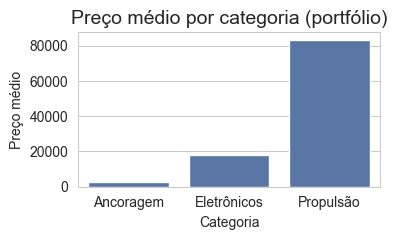

In [106]:
# Checando preço médio por categoria

df_category = df_product.groupby("category")["sale_price"].agg(
    preco_medio="mean",
    preco_mediano="median",
    preco_max="max"
).reset_index()

print(df_category)

plt.figure(figsize=(4, 2.5))

sns.barplot(
    data=df_category,
    x="category",
    y="preco_medio",
    color="#4C72B0"
)

plt.title("Preço médio por categoria (portfólio)", fontsize=14)
plt.xlabel("Categoria")
plt.ylabel("Preço médio")

plt.tight_layout()
plt.show()

#### Análise de Prejuízo por Produto

A análise evidencia que o prejuízo é amplamente distribuído no portfólio, com 127 dos 150 produtos apresentando resultado negativo no período.

No entanto, o impacto financeiro do prejuízo é altamente concentrado em um subconjunto de produtos, majoritariamente pertencentes à categoria de propulsão (motores).

A análise de preços por categoria confirma que produtos de propulsão possuem valores significativamente mais elevados, com média superior a R$ 83 mil, muito acima das demais categorias.

Esse fator amplifica o impacto financeiro das margens negativas, fazendo com que pequenas perdas relativas nesses produtos resultem em prejuízos absolutos expressivos.

Portanto, o problema não está apenas na incidência de prejuízo, mas na combinação entre margens negativas e alto valor unitário em produtos de maior ticket. Esse padrão sugere que ajustes na precificação ou na gestão de custos dos produtos de maior valor podem ter impacto desproporcional na melhoria do resultado financeiro do negócio.

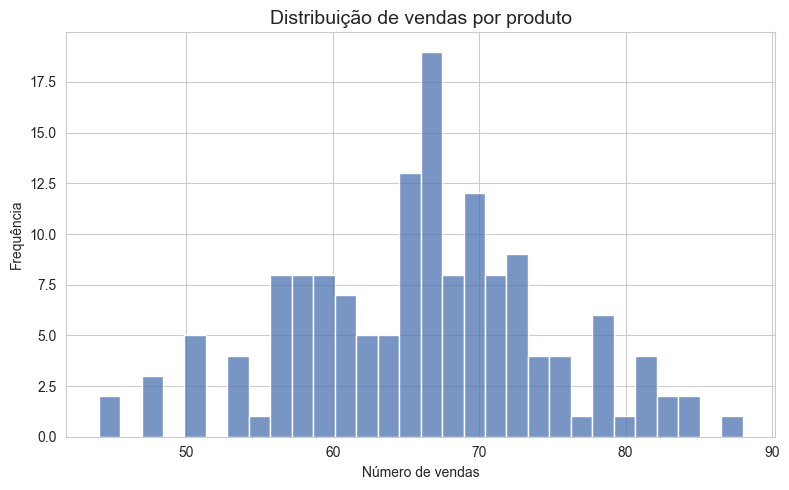

In [107]:
# Distribuição de vendas por produto

plt.figure(figsize=(8, 5))

sns.histplot(
    df_prod["num_vendas"],
    bins=30,
    color="#4C72B0"
)

plt.title("Distribuição de vendas por produto", fontsize=14)
plt.xlabel("Número de vendas")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

In [109]:
# Análise de Pareto


top_20_pct = int(len(df_prod) * 0.2)

df_pareto.head(top_20_pct)["num_vendas"].sum() / df_prod["num_vendas"].sum()

0.23648307225871654

=> Os 20% dos produtos mais vendidos geram apenas ~23.6% do total de vendas

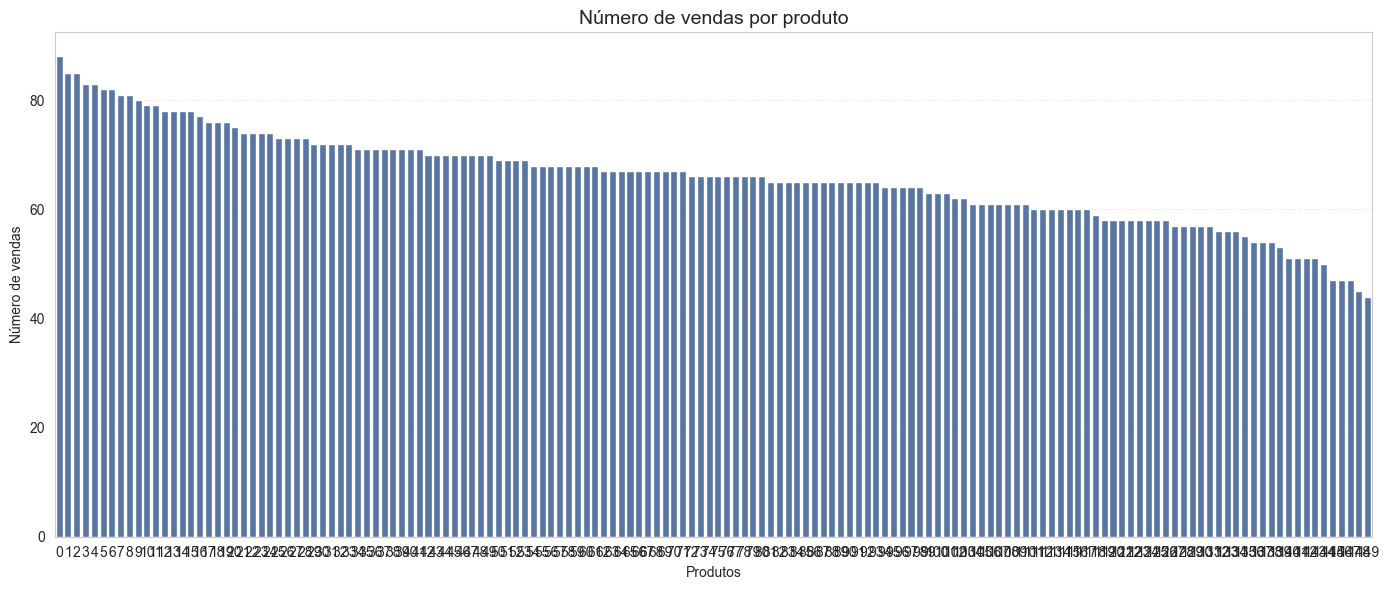

In [115]:
df_prod_sorted_by_qtd = df_prod.sort_values("num_vendas", ascending=False)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_prod_sorted_by_qtd,
    x=range(len(df_prod_sorted_by_qtd)),
    y="num_vendas",
    color="#4C72B0"
)

plt.title("Número de vendas por produto", fontsize=14)
plt.xlabel("Produtos")
plt.ylabel("Número de vendas")

plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

##### Distribuição de Vendas por Produto

A distribuição de vendas por produto apresenta um comportamento relativamente uniforme, sem concentração significativa em um pequeno grupo de itens.

O volume de vendas varia de 44 a 88 transações por produto, com uma queda gradual ao longo do ranking, sem rupturas ou pontos de inflexão relevantes.

Esse padrão indica que o portfólio possui uma distribuição equilibrada de demanda, onde não há dependência excessiva de produtos específicos para geração de volume.

Adicionalmente, a análise de concentração indica que os 20% dos produtos mais vendidos representam apenas cerca de 23.6% do volume total, reforçando a ausência de concentração relevante nas vendas.

In [125]:
# Margem por produto

df_prod["margem"] = df_prod["lucro"] / df_prod["total_amount"]

df_piores = df_prod.sort_values("margem").head(20)

pct_margem_negativa = (df_prod["margem"] < 0).mean()

print(f"{pct_margem_negativa:.2%}")
df_piores

84.67%


,product_id,name_y,lucro,total_amount,num_vendas,margem
71,72,Motor de Popa Volvo Hydro Dash 256HP,-3.980909e+07,63057815.65,78,-0.631311
82,83,Motor Diesel Yanmar Dash Nitro 184HP,-1.860701e+07,44377440.00,44,-0.419290
108,109,Cabo de Nylon Danforth Evo Aqua Mako,-1.020113e+05,328320.15,67,-0.310707
101,102,Cabo de Nylon Bruce Nexus,-9.644967e+04,335379.20,54,-0.287584
135,136,Cabo de Nylon Bruce Flux Hydro,-2.512370e+05,1049801.00,69,-0.239319
46,47,Rádio Simrad Tidal Aqua,-6.856029e+05,3184863.80,65,-0.215269
30,31,Transponder Furuno Pulse Axis,-9.297580e+05,4660491.45,66,-0.199498
41,42,Transponder Lowrance Axis,-3.331294e+05,2810048.65,67,-0.118549
73,74,Motor de Popa Honda Torque 228HP,-6.341764e+06,59764356.15,85,-0.106113
28,29,Rádio Simrad Orca,-1.724436e+06,17804264.00,70,-0.096855


=> Quase 85% dos produtos apresentam margem negativa

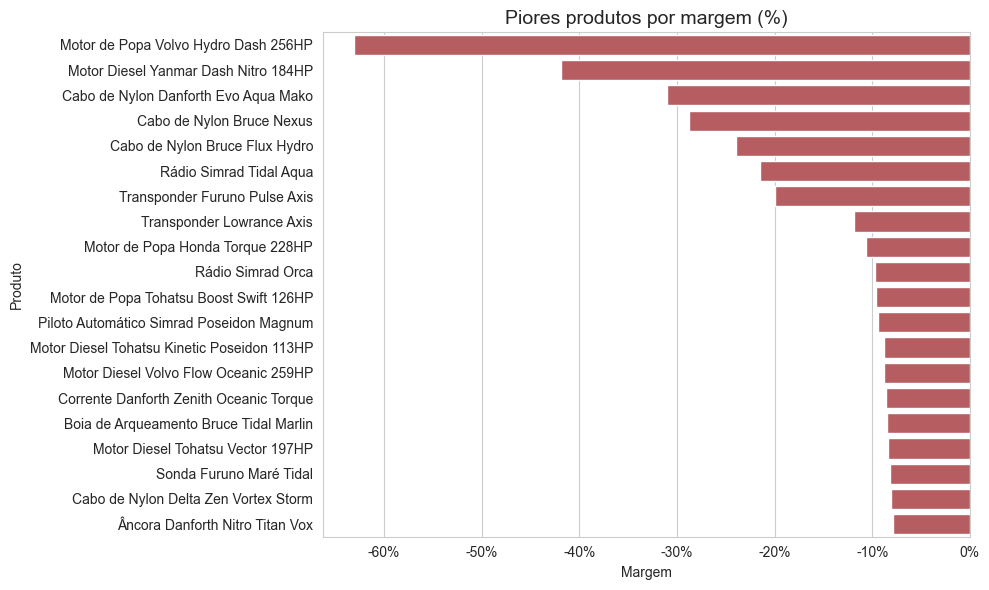

In [126]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_piores,
    x="margem",
    y="name_y",
    color="#C44E52"
)

import matplotlib.ticker as ticker
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:.0%}')
)

plt.title("Piores produtos por margem (%)", fontsize=14)
plt.xlabel("Margem")
plt.ylabel("Produto")

plt.tight_layout()
plt.show()

##### Margem por Produto

A análise de margem revela que aproximadamente 84.7% dos produtos operam com margem negativa no período analisado.

Esse percentual é significativamente superior ao observado na análise de prejuízo total, indicando que a ineficiência não está restrita a um subconjunto de produtos, mas distribuída de forma ampla pelo portfólio.

Isso sugere que muitos produtos apresentam desempenho econômico negativo, ainda que nem todos tenham impacto relevante no resultado final, seja por baixo volume de vendas ou menor valor unitário.

Dessa forma, o prejuízo do negócio é resultado de uma combinação entre ineficiência generalizada e concentração de impacto em produtos de maior valor.

- - - Análise de Clientes

In [127]:
# Distribuição de Clientes por Estado

df_estado_clientes = df_customer["state"].value_counts().reset_index()
df_estado_clientes.columns = ["state", "num_clientes"]

df_estado_clientes

,state,num_clientes
0,PA,8
1,BA,5
2,TO,4
3,SE,3
4,MA,3
5,PE,3
6,AM,3
7,CE,3
8,PB,3
9,AC,2


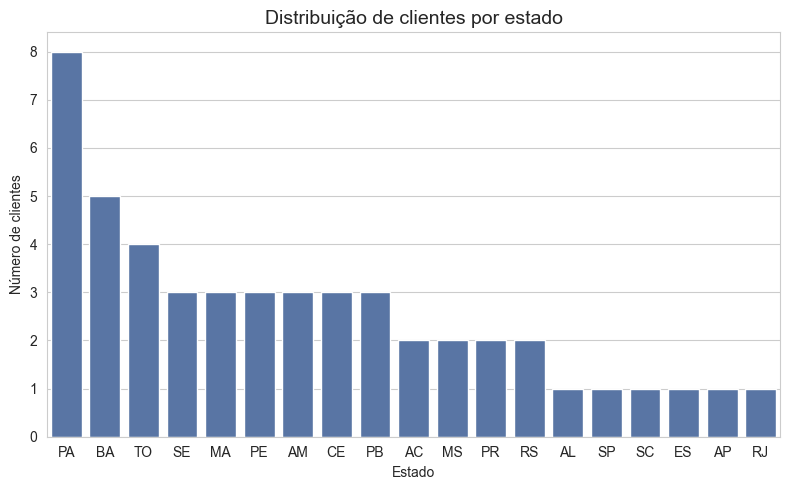

In [128]:
# Gráfico

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_estado_clientes,
    x="state",
    y="num_clientes",
    color="#4C72B0"
)

plt.title("Distribuição de clientes por estado", fontsize=14)
plt.xlabel("Estado")
plt.ylabel("Número de clientes")

plt.tight_layout()
plt.show()

In [130]:
# Distribuição de estados por vendas

df_estado_vendas = df.groupby("state").agg({
    "id_x": "count",
    "total_amount": "sum"
}).rename(columns={
    "id_x": "num_vendas",
    "total_amount": "receita"
}).reset_index()

df_estado_vendas

,state,num_vendas,receita
0,AC,398,1.025344e+08
1,AL,199,5.350016e+07
2,AM,608,1.544325e+08
3,AP,199,5.912683e+07
4,BA,955,2.415176e+08
5,CE,583,1.353386e+08
6,ES,217,6.202863e+07
7,MA,597,1.522286e+08
8,MS,382,9.046788e+07
9,PA,1664,4.576504e+08


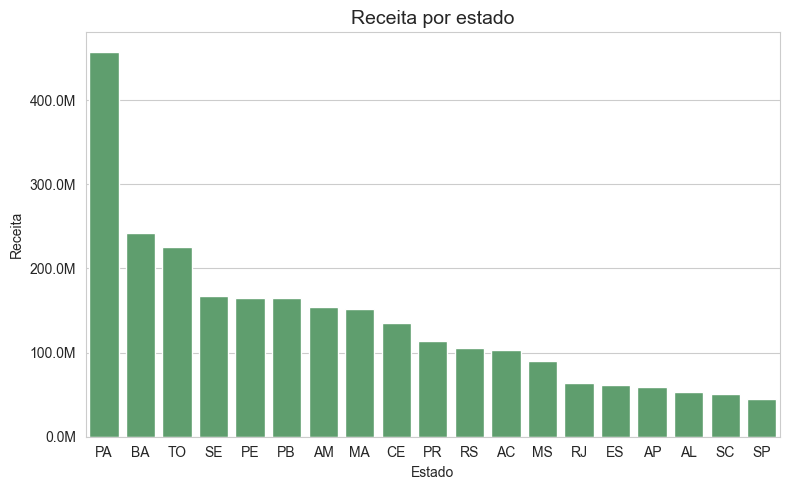

In [136]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_estado_vendas.sort_values("receita", ascending=False),
    x="state",
    y="receita",
    color="#55A868"
)

plt.title("Receita por estado", fontsize=14)
plt.xlabel("Estado")
plt.ylabel("Receita")

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)
plt.tight_layout()
plt.show()

In [137]:
# Por cidade
df_cidade_ref_clientes = df_customer["reference_city"].value_counts().reset_index()
df_cidade_ref_clientes.columns = ["reference_city", "num_clientes"]

df_cidade_ref_clientes

,reference_city,num_clientes
0,Santarém,4
1,Fortaleza do Tabocão,4
2,Fortaleza,3
3,Aracaju,3
4,São Luís,3
5,Santarém Novo,2
6,Rio Branco,2
7,João Pessoa,2
8,Porto Seguro,2
9,Itacoatiara,2


In [140]:
# Distribuição por cidade por vendas
df_cidade_ref_vendas = df.groupby("reference_city").agg({
    "total_amount": "sum"
}).reset_index().sort_values("total_amount", ascending=False)

df_cidade_ref_vendas

,reference_city,total_amount
8,Fortaleza do Tabocão,224946382.20
23,Santarém,218943444.55
1,Aracaju,167095845.05
26,São Luís,152228562.25
7,Fortaleza,135338567.60
11,João Pessoa,116765589.80
5,Candeias,109123448.45
21,Rio Grande,105859542.85
24,Santarém Novo,103728563.90
20,Rio Branco,102534414.50


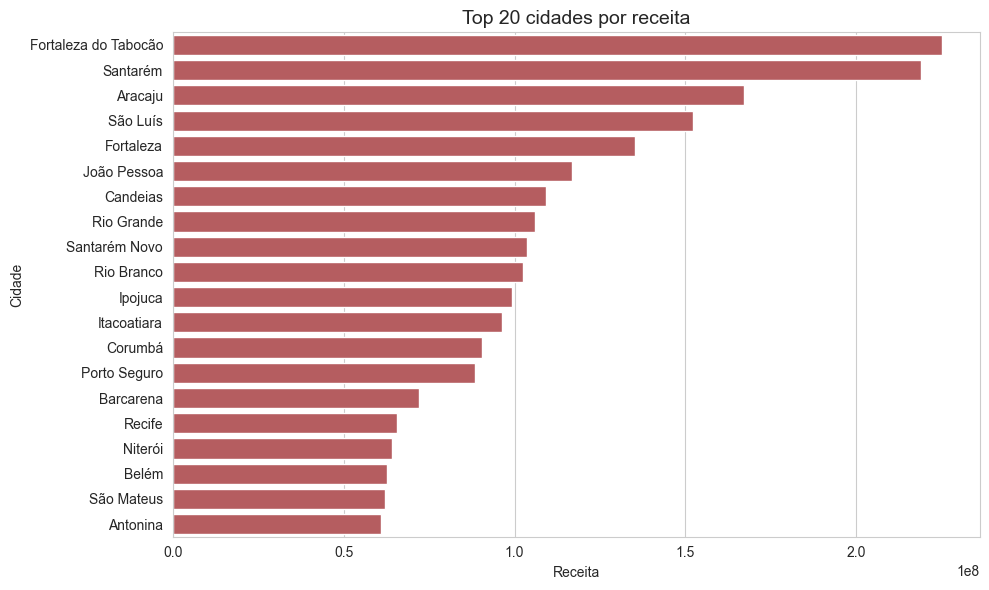

In [142]:
# Gráfico cidade por receita

top_n = 20

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_cidade_ref_vendas.head(top_n),
    x="total_amount",
    y="reference_city",
    color="#C44E52"
)

plt.title(f"Top {top_n} cidades por receita", fontsize=14)
plt.xlabel("Receita")
plt.ylabel("Cidade")

plt.tight_layout()
plt.show()

#### Distribuição Geográfica de Clientes e Receita

A análise geográfica indica uma distribuição bastante dispersa tanto de clientes quanto de receita, sem concentração relevante em estados ou cidades específicas.

Mesmo regiões com poucos clientes podem gerar volumes significativos de receita, sugerindo que o desempenho financeiro não está diretamente associado à concentração geográfica, mas sim a fatores como ticket médio e mix de produtos.

In [148]:
df_client = (
    df.groupby('client_id')
      .agg(
          receita_total=('total_amount', 'sum'),
          lucro_total=('lucro', 'sum'),
          prejuizo_total=('prejuizo', 'sum'),
          num_transacoes=('client_id', 'count'),
          margem_media=('lucro', lambda x: x.sum() / df.loc[x.index, 'total_amount'].sum())
      )
      .reset_index()
)

# Classificação inicial de clientes
def classificar_cliente(row):
    if row['lucro_total'] > 0:
        return 'Lucrativo'
    elif row['lucro_total'] < 0:
        return 'Prejuízo'
    else:
        return 'Break-even'

df_client['categoria_cliente'] = df_client.apply(classificar_cliente, axis=1)

df_client

,client_id,receita_total,lucro_total,prejuizo_total,num_transacoes,margem_media,categoria_cliente
0,1,51092500.05,-2378575.81,114,190,-0.05,Prejuízo
1,2,65652931.35,-4042806.80,137,220,-0.06,Prejuízo
2,3,59575349.10,-5133819.13,131,207,-0.09,Prejuízo
3,4,50691754.40,-2607050.78,128,207,-0.05,Prejuízo
4,5,58592802.70,-3051672.24,128,202,-0.05,Prejuízo
5,6,53225818.95,-3388285.37,128,201,-0.06,Prejuízo
6,7,47507921.80,-1991363.95,130,207,-0.04,Prejuízo
7,8,52156129.50,-1886151.23,126,208,-0.04,Prejuízo
8,9,66788855.35,-3411095.34,143,218,-0.05,Prejuízo
9,10,51674436.80,-1648473.08,143,203,-0.03,Prejuízo


In [150]:
df_client['categoria_cliente'].value_counts(normalize=True)

categoria_cliente
Prejuízo   1.00
Name: proportion, dtype: float64

In [151]:
lucro_total = df_client['lucro_total'].sum()
lucro_positivos = df_client[df_client['lucro_total'] > 0]['lucro_total'].sum()
lucro_negativos = df_client[df_client['lucro_total'] < 0]['lucro_total'].sum()

print("Lucro positivo / total:", lucro_positivos / lucro_total)
print("Lucro negativo / total:", lucro_negativos / lucro_total)

Lucro positivo / total: -0.0
Lucro negativo / total: 1.0


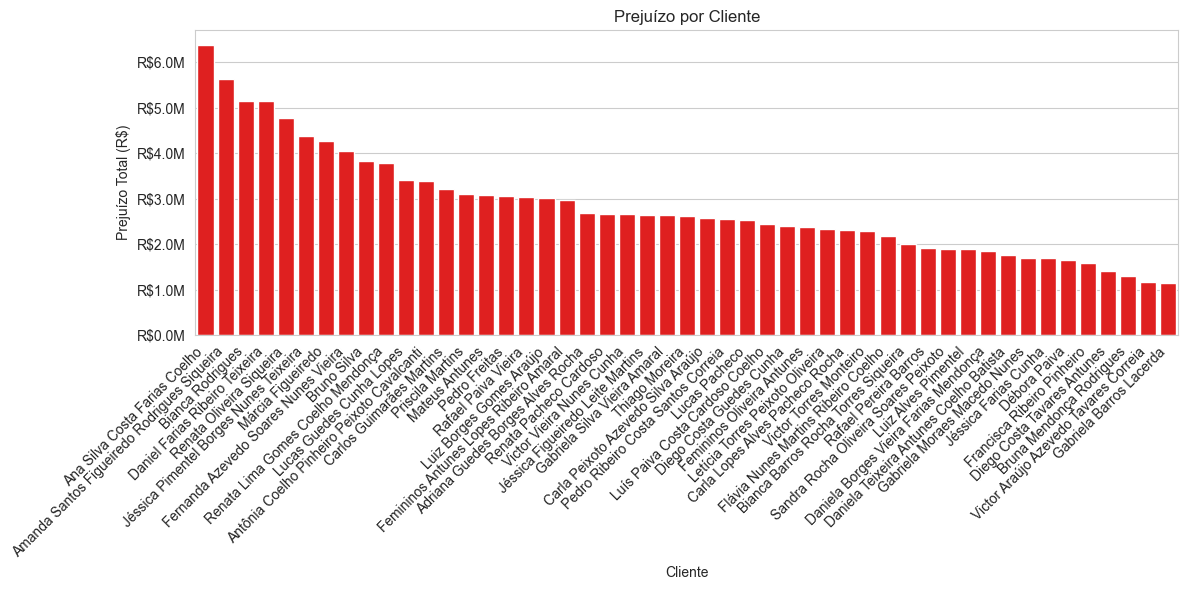

In [159]:
# Merge para pegar o nome do cliente
df_plot = df_client.merge(df_customer[['client_id', 'name']], on='client_id', how='left')

# Prejuízo absoluto (positivo)
df_plot['prejuizo_abs'] = -df_plot['lucro_total']

# Ordenar do maior para o menor prejuízo
df_plot = df_plot.sort_values('prejuizo_abs', ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_plot, 
    x='name', 
    y='prejuizo_abs', 
    color='red'
)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Cliente')
plt.ylabel('Prejuízo Total (R$)')
plt.title('Prejuízo por Cliente')
formatter = ticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.show()

**Insight**

A análise da base de clientes revelou que todos os 49 clientes atuais geram prejuízo, independentemente do volume de compras ou região de atuação. O prejuízo é distribuído entre todos, sem nenhum cliente positivo para compensar as perdas.

O gráfico de prejuízo por cliente mostra que alguns clientes concentram perdas maiores, mas mesmo os menores contribuem negativamente para o resultado.

Esse padrão indica que o problema não está na concentração ou dependência de clientes específicos, mas sim em fatores estruturais do negócio, como margens insuficientes, custos elevados ou precificação inadequada.

Consequentemente, qualquer ação estratégica voltada para clientes, como retenção ou fidelização, não resolverá a questão central. O foco deve ser otimizar custos, ajustar precificação e revisar a rentabilidade por produto para reverter a situação.

In [162]:
# Agrupar por cliente
df_freq = df.groupby('client_id').agg(
    num_transacoes=('client_id', 'count'),
    quantidade_total=('quantity', 'sum'),
    receita_total=('total_amount', 'sum'),
    prejuizo_total=('lucro', lambda x: -x.sum())  # transformar em positivo
).reset_index()

# Adicionar nome do cliente
df_freq = df_freq.merge(df_customer[['client_id', 'name']], on='client_id', how='left')

df_freq

,client_id,num_transacoes,quantidade_total,receita_total,prejuizo_total,name
0,1,190,1494,51092500.05,2378575.81,Femininos Oliveira Antunes
1,2,220,2024,65652931.35,4042806.80,Fernanda Azevedo Soares Nunes Vieira
2,3,207,1611,59575349.10,5133819.13,Daniel Farias Ribeiro Teixeira
3,4,207,1681,50691754.40,2607050.78,Thiago Moreira
4,5,202,1656,58592802.70,3051672.24,Pedro Freitas
5,6,201,1654,53225818.95,3388285.37,Antônia Coelho Pinheiro Peixoto Cavalcanti
6,7,207,1648,47507921.80,1991363.95,Bianca Barros Rocha Torres Siqueira
7,8,208,1678,52156129.50,1886151.23,Luiz Alves Pimentel
8,9,218,1691,66788855.35,3411095.34,Lucas Guedes Cunha Lopes
9,10,203,1585,51674436.80,1648473.08,Débora Paiva


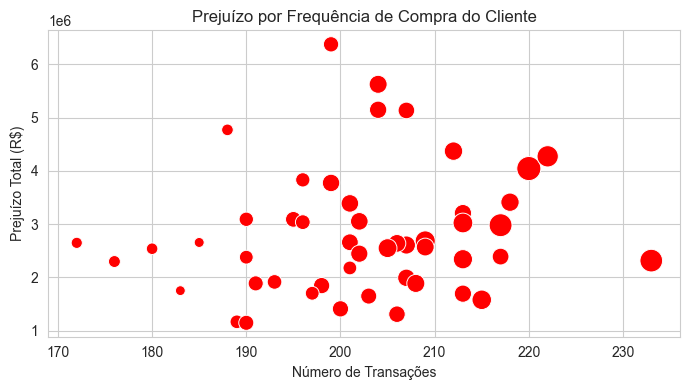

In [166]:
plt.figure(figsize=(7,4))

sns.scatterplot(
    data=df_freq, 
    x='num_transacoes', 
    y='prejuizo_total',
    size='quantidade_total',
    sizes=(50, 300),
    color='red',
    legend=False
)

plt.xlabel('Número de Transações')
plt.ylabel('Prejuízo Total (R$)')
plt.title('Prejuízo por Frequência de Compra do Cliente')

plt.tight_layout()
plt.show()

**Insight**: A análise da relação entre frequência de compra e prejuízo por cliente não identificou qualquer correlação relevante. Clientes com maior número de transações não apresentam, necessariamente, maior impacto negativo, e o mesmo padrão se observa para clientes de baixo volume.

Esse comportamento indica que o prejuízo não está associado ao nível de atividade dos clientes, mas sim a fatores estruturais do negócio, como margens insuficientes e custos elevados por transação.

Em outras palavras, o problema não está em quem compra mais ou menos, mas sim no fato de que cada venda, independentemente do cliente, tende a gerar prejuízo.

Em resumo: **Clientes NÃO explicam o prejuízo do negócio**